# EE2211 – Python Clinic Session 3
This notebook introduces key Python libraries, explains fundamental matrix operations step-by-step, and shows sample code for linear regression, polynomial regression, and ridge regression. 

# 1. NumPy & Scikit-Learn in Machine Learning

Two of the most essential Python libraries in any ML workflow are **NumPy** and **scikit-learn (sklearn)**. Together, they provide the numerical backbone and high-level algorithms you need to build predictive models efficiently.

These 2 libraries will be tested in the midterm. `Pandas` will not be tested.

---

## What are These Libraries?

| Library | Role | Key Strengths |
|---|---|---|
| **NumPy** | Numerical computing foundation | Fast array operations, linear algebra, broadcasting |
| **scikit-learn** | ML & Data preprocessing | OneHotEncoder, train_test_split, PolynomialFeatures |

### NumPy
NumPy provides the `ndarray` — a powerful n-dimensional array object. Almost every ML library in Python (including sklearn, TensorFlow, and PyTorch) builds on top of NumPy arrays. It enables:
- Vectorized math operations (much faster than pure Python loops)
- Matrix multiplication, dot products, and linear algebra

```python
import numpy as np

# Create feature matrix X and target vector y
X = np.array([[1,2], [2,3], [3,4], [4,1], [5,7]])  # shape: (5, 2)
y = np.array([2.1, 4.0, 5.9, 8.1, 9.8]) # shape: (5,), 1D array
y2 = np.array([[2.1], [4.0], [5.9], [8.1], [9.8]]) # shape: (5,1)
```

**When we create dataset including x and y, make sure to use 2D array for both X and y. Otherwise, we will get an error.**

### scikit-learn
scikit-learn provides a **unified API** for dozens of ML algorithms. Every model follows the same pattern:
1. **Instantiate** the model: `model = SomeModel()`
2. **Fit** (train) on data: `model.fit(X, y)`
3. **Predict** on new data: `y_pred = model.predict(X_new)`

This consistency means once you learn one model, you can apply the same workflow to hundreds of others.

### Documentation:

- NumPy: https://numpy.org/doc/stable/user/absolute_beginners.html
- scikit-learn: https://scikit-learn.org/stable/api/index.html

## 1.1 Matrix Determinant and Inverse
We define a square matrix and compute its determinant and inverse.

In [3]:
import numpy as np
from numpy.linalg import det, inv

A = np.array([[1, 2],
              [3, 4]])

det_A = det(A) # AD - BC = 1*4 - 2*3 = 4 - 6 = -2
A_inv = inv(A)

print("A =\n", A)
print("det(A) =", det_A)
print("A_inv =\n", A_inv)

# Verify is A is invertible
if det_A != 0:
    print("A is invertible.")
else:
    print("A is not invertible.")

# Or use the rank to check invertibility
rank_A = np.linalg.matrix_rank(A)
if rank_A == A.shape[0]: # Full rank means invertible
    print("A is invertible based on rank.")
else:
    print("A is not invertible based on rank.")

A =
 [[1 2]
 [3 4]]
det(A) = -2.0000000000000004
A_inv =
 [[-2.   1. ]
 [ 1.5 -0.5]]
A is invertible.
A is invertible based on rank.


### Key functions used in the code above

- **det(·)** — Computes the determinant of a square matrix (NumPy). Useful when you want to check if a matrix is invertible (det ≠ 0).
- **inv(·)** — Computes the inverse of a square matrix (NumPy). Only valid if the matrix is nonsingular (invertible).

## 1.2 Matrix Rank and Transpose

In [ ]:
from numpy.linalg import matrix_rank

X = np.array([[1, 4, 3],
              [0, 4, 2],
              [1, 8, 5]])

print("Rank of X:", matrix_rank(X))
print("X =\n", X)
print("X Transpose =\n", X.T)

Rank of X: 2
X =
 [[1 4 3]
 [0 4 2]
 [1 8 5]]
X Transpose =
 [[1 0 1]
 [4 4 8]
 [3 2 5]]


Why this matrix is not invertible? 
- Rank is 2, not full rank

Why rank is 2? 
- R3 = R1 + R2

## 1.3 Matrix Multiplication

In [ ]:
X = np.array([[1, 4],
              [0, 4],
              [3, -2]]) # 3x2 matrix, 3 rows, 2 columns
 
y = np.array([3, 0.5, 4]) # 3x1 vector, 3 rows, 1 column

z = X.T @ y
print("Vector-matrix product:")
print(z)

X2 = np.array([[1, 4, 3],
               [0, 4, 2]]) # 2x3 matrix, 2 rows, 3 columns

Q = X @ X2
print("Matrix product:")
print(Q)

Vector-matrix product:
[15.  6.]
Matrix product:
[[ 1 20 11]
 [ 0 16  8]
 [ 3  4  5]]


In [7]:
X.shape

(3, 2)

## 1.4 Even, Over, and Under-determined Systems

In [ ]:
# Even-determined. For X, m = d
X = np.array([[1, 1],
              [1, -2]])
y = np.array([4, 1])
w_even = inv(X) @ y
print("Even-determined solution:", w_even)

In [ ]:
# Over-determined (Least Squares). For X, m > d
X = np.array([[1, 1],
              [1, -1],
              [1, 0]])
y = np.array([1, 0, 2])
w_over = inv(X.T @ X) @ X.T @ y 
print("Over-determined solution:", w_over)

In [ ]:
# Under-determined (Least Norm). For X, m < d
X = np.array([[1, 2, 3],
              [1, -2, 3]])
y = np.array([2, 1])
w_under = X.T @ inv(X @ X.T) @ y
print("Under-determined solution:", w_under)

### To save you some time and effort, you can use the following without worrying about the form of X (over-determined or under-determined)

In [ ]:
if X.shape[0] > X.shape[1]:
    w_poly = inv(X.T @ X) @ X.T @ y  #primal form (m>d) 
else: 
    w_poly = X.T @ inv(X @ X.T) @ y  #dual form (m<d)

### Or:

In [ ]:
# Or simply use the pseudo-inverse, which is robust for both forms
w_poly = np.linalg.pinv(X) @ y  # robust for both forms

## 1.5 One-Hot Encoding

During classification, we often encounter categorical features (e.g., color, type, etc.) that cannot be directly used in mathematical models. We need to convert these categorical features into a numerical format that machine learning algorithms can understand.
For binary classification, can simply convert to -1 and +1. For multi-class classification (e.g., 3 classes ['red', 'green', 'blue']), we can use **one-hot encoding**.

```
Color       →   Color_red  Color_green  Color_blue
─────────       ─────────────────────────────────
red         →      1           0            0
green       →      0           1            0
blue        →      0           0            1
```

---

### Using sklearn's `OneHotEncoder`

[Note:]
- `fit_transform`` is used on training data to learn the encoding scheme and apply it.
- `transform` is used on test data to ensure the same encoding scheme is applied.

In [ ]:
import numpy as np
from sklearn.preprocessing import OneHotEncoder

# Raw categorical feature
colors = np.array([['red'], ['green'], ['blue'], ['red'], ['green']])

# Always set sparse_output=False to get a numpy array output, so that we can use numpy operations on it later
encoder = OneHotEncoder(sparse_output=False)
encoded = encoder.fit_transform(colors) # Input should be 2D

print("Categories:", encoder.categories_)
print("Encoded array:\n", encoded)

Categories: [array(['blue', 'green', 'red'], dtype='<U5')]
Encoded array:
 [[0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]]


*   scikit-learn documentation for `OneHotEncoder`: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html

## 1.6 Linear Regression and Polynomial Regression Example

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures

X = np.array([[3], [4], [5], [6], [7]])
y = np.array([5, 4, 3, 2, 1])

poly = PolynomialFeatures(1) # linear regression is a special case of polynomial regression with degree=1
P = poly.fit_transform(X)

W = inv(P.T @ P) @ P.T @ y # Over-determined case, use the primal form
print("W =\n", W)

y_pred = P @ W
print("Predictions =\n", y_pred)

MSE = mean_squared_error(y, y_pred)
print("MSE =", MSE)

W =
 [0.8 0.8]
Predictions =
 [3.2 4.  4.8 5.6 6.4]
MSE = 6.480000000000001


**This linear model can give a perfect fit function $f(x)= -1*x + 8$**

### MSE

mean_squared_error (MSE) is a function used to measure how good or bad a regression model is.

Mathematical fomular:
$ MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 $

It computes the average squared difference between:

- The true values (y)
- The predicted values (y_pred)

Usage:
`MSE = mean_squared_error(y, y_pred)`

scikit-learn documentation for mean_squared_error: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html

### `PolynomialFeatures`

- `PolynomialFeatures` = a way to expand your input data into higher powers (like $x^2, x^3, {x_1}{x_2}$, etc) so that a simple linear regression can model curves, not just straight lines. Bias column automatically included.

- `PolynomialFeatures` expects 2D input: either a column vector (`n_samples, 1`) or a feature matrix (`n_samples, n_features`).

- scikit-learn documentation for `PolynomialFeatures`: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.htmlMSE)

### PolynomialFeatures: Transforming $\text{X}$ to $\text{P}$
#### Code Breakdown

```python
order = 2
poly = PolynomialFeatures(order) 
P = poly.fit_transform(X)
```

#### Step 1: Creating the Transformer
`poly = PolynomialFeatures(order)`
* **Creates** a <mark>feature matrix</mark> with polynomial features up to **degree 2**
* **Configuration:** Sets up the rules for transformation but doesn't process data yet
* **Example:** For input $[a, b]$, it can create $[1, a, b, a^2, ab, b^2]$
* **Note:** The <mark>**bias/offset column** is *automatically included*!</mark>

#### Step 2: Fitting and Transforming
`P = poly.fit_transform(X)` :

* **Applies** the polynomial expansion to $\text{X}$
* **Creates** new <mark>data matrix</mark> by combining original features polynomially

In [12]:
# Tutorial 6 Qustion 2
import numpy as np
from numpy.linalg import inv
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Given data
X = np.array([[-10], [-8], [-3], [-1], [2], [8]])
y = np.array([[5], [5], [4], [3], [2], [2]])

In [ ]:
# (a) 3rd-order polynomial regression: generate polynomial features
poly_features = PolynomialFeatures(degree=3) # generates [1, x, x^2, x^3] for each input x
P = poly_features.fit_transform(X) # P is the new design matrix with polynomial features, fit_transform returns the polynomial features for X, which is w0 + w1*x + w2*x^2 + w3*x^3
print(P)

# Compute w (without ridge)
if P.shape[0] > P.shape[1]: # this question P has m=6 and d=4, we use the primal form
    w_poly = inv(P.T @ P) @ P.T @ y  #primal form (m>d) 
else: 
    w_poly = P.T @ inv(P @ P.T) @ y  #dual form (m<d)

# Alternative method:
# w_poly = np.linalg.pinv(P) @ y  # robust for both forms

print('w_poly using the 3rd-order polynomial model:')
print(w_poly)

PolynomialFeatures(degree=3)
[[    1.   -10.   100. -1000.]
 [    1.    -8.    64.  -512.]
 [    1.    -3.     9.   -27.]
 [    1.    -1.     1.    -1.]
 [    1.     2.     4.     8.]
 [    1.     8.    64.   512.]]
w_poly using the 3rd-order polynomial model:
[[ 2.68935636]
 [-0.37722517]
 [ 0.01343815]
 [ 0.00285772]]


In [ ]:
# (b) Given a test point {𝑥 = 9}, predict 𝑦 using the polynomial model.
X_t = np.array([[9]])
print("X_t:")
print(X_t)
P_t = poly_features.transform(X_t) # fit_transform is used for training data, transform is used for test data, it generates the polynomial features for the test point X_t, which is [1, 9, 9^2, 9^3]
print("P_t:")
print(P_t)
y_predict_poly = P_t @ w_poly
print('y_predict_poly for x=9 using the 3rd-order polynomial model:')
print(y_predict_poly)

## 1.7 Ridge Regression Example

### Primal Form

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

X = np.array([[1,0,1], [1,-1,1]])
y = np.array([[0], [1]])

poly = PolynomialFeatures(3)
P = poly.fit_transform(X)

lamb = 0.0001
reg = lamb * np.identity(P.shape[1]) # regularization term, lambda * I (d*d matrix)

w_ridge = inv(P.T @ P + reg) @ P.T @ y # primal form is used here

print("Ridge weights =\n", w_ridge)

Ridge weights =
 [[ 9.99967369e-07]
 [ 9.99973281e-07]
 [-9.99980001e-02]
 [ 9.99970666e-07]
 [ 9.99975100e-07]
 [-9.99980000e-02]
 [ 9.99969075e-07]
 [ 9.99980001e-02]
 [-9.99980000e-02]
 [ 9.99971803e-07]
 [ 9.99968279e-07]
 [-9.99980000e-02]
 [ 9.99965550e-07]
 [ 9.99980001e-02]
 [-9.99980001e-02]
 [ 9.99969075e-07]
 [-9.99980000e-02]
 [ 9.99980001e-02]
 [-9.99980000e-02]
 [ 9.99965778e-07]]


### Dual Form

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

X = np.array([[1,0,1], [1,-1,1]])
y = np.array([[0], [1]])

poly = PolynomialFeatures(3)
P = poly.fit_transform(X)

lamb = 0.0001

# We need to use P.shape[0] for the regularization term in the dual form, because in the dual form, we are inverting a matrix of size m x m
reg = lamb * np.identity(P.shape[0]) # regularization term, lambda * I (m*m matrix)

w_ridge = P.T @ inv(P @ P.T + reg) @ y

print("Ridge weights =\n", w_ridge)

Ridge weights =
 [[ 9.99970001e-07]
 [ 9.99970001e-07]
 [-9.99980000e-02]
 [ 9.99970001e-07]
 [ 9.99970001e-07]
 [-9.99980000e-02]
 [ 9.99970001e-07]
 [ 9.99980000e-02]
 [-9.99980000e-02]
 [ 9.99970001e-07]
 [ 9.99970001e-07]
 [-9.99980000e-02]
 [ 9.99970001e-07]
 [ 9.99980000e-02]
 [-9.99980000e-02]
 [ 9.99970001e-07]
 [-9.99980000e-02]
 [ 9.99980000e-02]
 [-9.99980000e-02]
 [ 9.99970001e-07]]


### Key points used in the code above
In ordinary least squares, the solution is:

$ \text{w} = (P^T P)^{-1} P^T y $

But this can fail if:

- $P^TP$ is singular (not invertible)

- Features are highly correlated, which leads to unstable estimates of the coefficients w

- The system may overfit the training data, leading to poor generalization on unseen data

So we modify it using ridge regression by adding a regularization term $\lambda I$ to the normal equation:

$ w_{\text{ridge}} = (P^T P + \lambda I)^{-1} P^T y $

### Setting Regularization Parameter

`lamb = 0.0001`

- This is the regularization parameter $𝜆$, it controls the strength of the penalty
- The larger the value of $𝜆$, the stronger the regularization, which can help prevent overfitting but may lead to underfitting if set too high.

Why not call it `lambda`?

- `lambda` is a reserved keyword in Python (used for anonymous functions).

### Regularization Matrix Construction
```python
reg = lamb * np.identity(P.shape[1])
```

#### What this line does

This line creates a **regularization matrix** — a scaled identity matrix used to prevent overfitting in models like **Ridge Regression** (also called L2 regularization).

---

#### Breaking it down

| Part | Meaning |
|------|---------|
| `P.shape[1]` | The number of **columns** in matrix `P` (i.e., the number of features) |
| `np.identity(P.shape[1])` | Creates a **square identity matrix** of that size — 1s on the diagonal, 0s everywhere else |
| `lamb` | The **regularization strength** (λ) — a scalar you choose. Larger = more regularization |
| `lamb * np.identity(...)` | Scales the identity matrix by λ, producing the regularization matrix |

---

This ensures the matrix is always **invertible** and **penalizes large weights**, which helps the model generalize better to new data.

## Primal vs. Dual Form

Both forms yield identical predictions, differing only in **computational cost**.

**Primal** — inverts a (d × d) matrix (d = features):
$$\mathbf{w} = (X^\top X + \lambda I)^{-1} X^\top \mathbf{y}$$

**Dual** — inverts an (m × m) matrix (m = samples):
$$\mathbf{w} = X^\top(XX^\top + \lambda I)^{-1} \mathbf{y}$$

# 2. Sample Exam-Style Questions

## 2.1 Trial Quiz Q11:

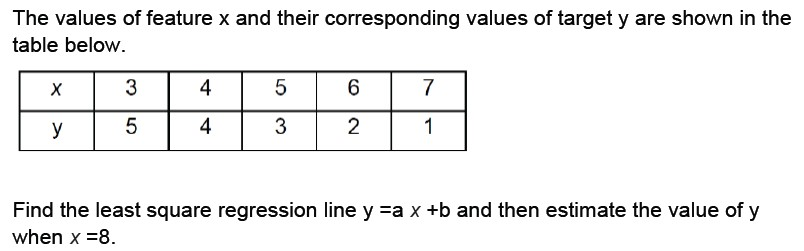


In [21]:
# 1. Define Training Data
X = np.array([[3], [4], [5], [6], [7]]) # Input features (Independent variable)
y = np.array([5, 4, 3, 2, 1])           # Target labels (Dependent variable)

# 2. Feature Transformation (Adding the Bias/Intercept term)
# Order 1 means a linear model: y = w0 + w1*x
order = 1 
poly = PolynomialFeatures(order) 
P = poly.fit_transform(X) # P now contains a column of 1s (bias) and the column X

print(P)

# Or we can manually add the bias term:
# P = np.hstack((np.ones((X.shape[0], 1)), X)) # Add a column of 1s for the bias term

# 3. Over-determined. Solve using the Least Squares Solution: W = (P^T * P)^-1 * P^T * y 
W = inv(P.T @ P) @ P.T @ y
print(f"Weights (Bias, W1):\n{W}\n")

# 4. Make Predictions on Training Data
y_predict = P @ W
print(f"Predicted Y values:\n{y_predict}\n")

# 5. Evaluate the Model
MSE1 = mean_squared_error(y, y_predict)
print(f"Mean Squared Error (MSE): {MSE1}\n")

# Or we can compute MSE manually:
MSE_manual = np.mean((y - y_predict) ** 2)
print(f"Mean Squared Error (MSE) computed manually: {MSE_manual}\n")

# 6. Predict on New Data
Xt = np.array([[8]]) # New sample
Pt = poly.transform(Xt) # Transform new sample to include bias
yt = Pt @ W
print(f"Prediction for X=8: {yt}")

[[1. 3.]
 [1. 4.]
 [1. 5.]
 [1. 6.]
 [1. 7.]]
Weights (Bias, W1):
[ 8. -1.]

Predicted Y values:
[5. 4. 3. 2. 1.]

Mean Squared Error (MSE): 2.3665827156630354e-30

Mean Squared Error (MSE) computed manually: 2.3665827156630354e-30

Prediction for X=8: [3.55271368e-15]


> Use `poly.transform()` (not `fit_transform()`) on test data — this ensures the same transformation learned from training data is applied, without refitting.

## 2.2 Trial Quiz Q15: Multiple Linear Regression

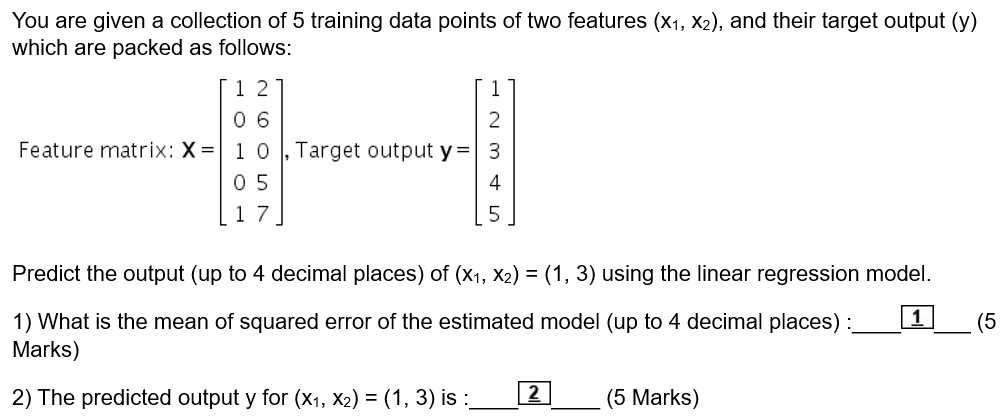

In [26]:
# 1. Define Multi-feature Training Data
X = np.array([[1, 2], [0, 6], [1, 0], [0, 5], [1, 7]])
y = np.array([1, 2, 3, 4, 5])

# 2. Add Bias Term
order = 1 
poly = PolynomialFeatures(order) 
P = poly.fit_transform(X) # P contains [1, x1, x2]

# Or we can manually add the bias term:
# P = np.array([[1, 1, 2], [1, 0, 6], [1, 1, 0], [1, 0, 5], [1, 1, 7]]) # Manually adding bias term

# 3. Over-determined. Solve for Weights
W = inv(P.T @ P) @ P.T @ y
print(f"Weights (Bias, W1, W2):\n{W}\n")

# 4. Predict and Evaluate
y_predict = P @ W

MSE = mean_squared_error(y, y_predict)
print(f"MSE: {MSE:.4f}\n")

# 5. Predict on New Multi-feature Data point
Xt = np.array([[1, 3]])
Pt = poly.transform(Xt)
yt = Pt @ W
print(f"Prediction for X=[1, 3]: {yt}")

Weights (Bias, W1, W2):
[1.13207547 0.8490566  0.33962264]

MSE: 1.3887

Prediction for X=[1, 3]: [3.]


## 2.3 Classification - TUT06 Q5
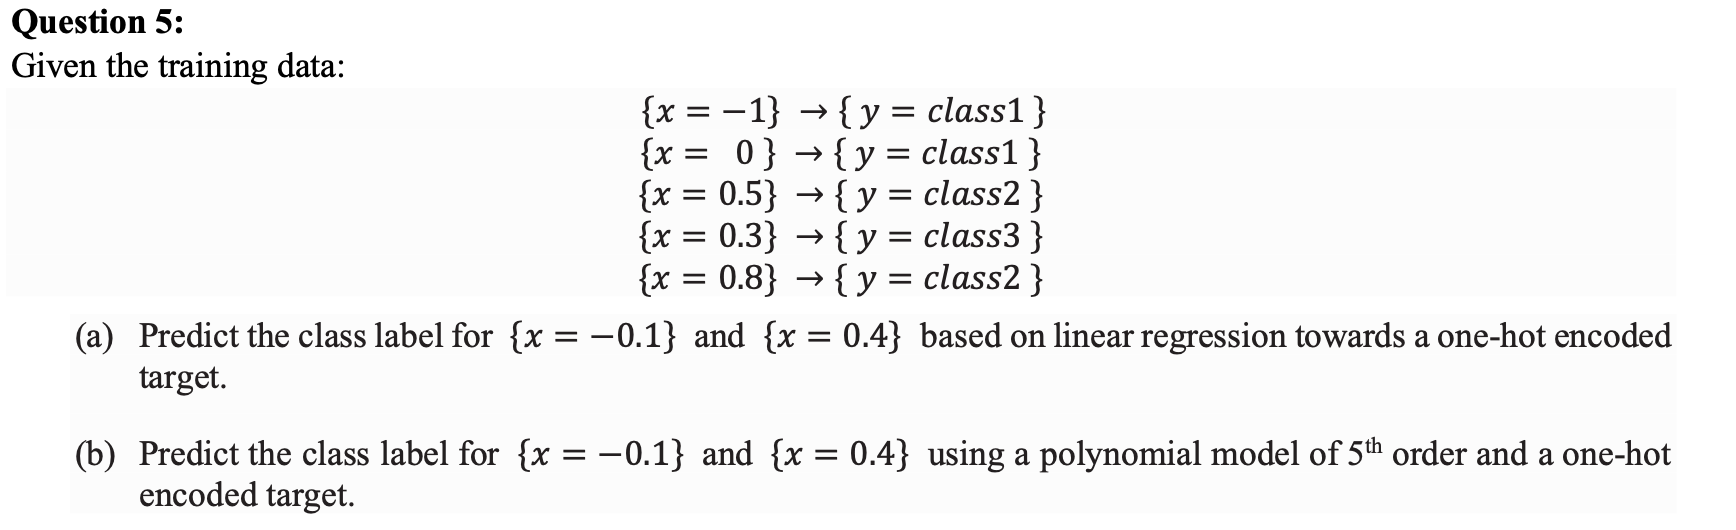

In [ ]:
import numpy as np 
from numpy.linalg import inv 
from sklearn.preprocessing import PolynomialFeatures 
from sklearn.preprocessing import OneHotEncoder

# We can manually add the bias term to X
# X_linear = np.array([[1, -1], [1, 0], [1, 0.5], [1, 0.3], [1, 0.8]])

# Or we can use PolynomialFeatures to automatically generate the bias term and polynomial features
X = np.array([[-1], [0], [0.5], [0.3], [0.8]])
linear = PolynomialFeatures(1) # Change the scaler X to a array of features with order no more than 1. [x] -> [x^0, x^1]
X_linear = linear.fit_transform(X) # bias term included

# print(X_linear)

y_raw = np.array([[1], [1], [2], [3], [2]]) 

# Always set sparse_output to False to force the encoded matrix to be a numpy array
encoder=OneHotEncoder(sparse_output=False)
Y_onehot = encoder.fit_transform(y_raw)

### a

In [ ]:
## (a) Linear regression for classification 
W = inv(X_linear.T @ X_linear) @ X_linear.T @ Y_onehot # over_determined system
print(f"W=\n{W}\n") 

X_t = np.array([[-0.1], [0.4]])
X_t_linear = linear.transform(X_t) # bias term included
y_predict_raw = X_t_linear @ W 
print(f"y_predict_raw=\n{y_predict_raw}\n") 

# Converts the predicted values into one-hot encoded class predictions
y_predict_class = [[1 if y == max(x) else 0 for y in x] for x in y_predict_raw] # Find the max value in each row of y_predict_raw, and set the corresponding position to 1, others to 0
print(f"y_predict_class=\n{y_predict_class}\n") 


W=
[[ 0.47798742  0.33333333  0.18867925]
 [-0.64989518  0.55555556  0.09433962]]

y_predict_raw=
[[0.54297694 0.27777778 0.17924528]
 [0.21802935 0.55555556 0.22641509]]

y_predict_class=
[[1, 0, 0], [0, 1, 0]]



### b

In [ ]:
## (b) Polynomial regression (order = 5)

## Generate polynomial features 
order = 5 
poly = PolynomialFeatures(order) 
P = poly.fit_transform(X)

# Compute w (without ridge), check if the system is over-determined or under-determined, and use the appropriate formula to compute the weights for the polynomial regression model
if P.shape[0] > P.shape[1]: 
    w_poly = inv(P.T @ P) @ P.T @ Y_onehot  #primal form (m>d), over-determined system
else: 
    w_poly = P.T @ inv(P @ P.T) @ Y_onehot  #dual form (m<d), under-determined system

# Or
# w_poly = np.linalg.pinv(P) @ Y_onehot  # Handles both cases automatically

print(f"w_poly=\n{w_poly}\n") 

# predict new data
P_t = poly.transform(X_t) 
yp_predict = P_t @ w_poly 
print(f"yp_predict=\n{yp_predict}\n") 

yp_class_predict = [[1 if y == max(x) else 0 for y in x] for x in yp_predict] 
print(f"yp_class_predict=\n{yp_class_predict}\n")

w_poly=
[[ 1.00000000e+00 -4.26325641e-14 -1.42108547e-13]
 [-5.30313768e+00 -3.70234958e+00  9.00548727e+00]
 [ 5.21976232e+00  1.08728407e+01 -1.60926030e+01]
 [ 6.66624941e+00  9.46978846e+00 -1.61360379e+01]
 [-6.47651463e+00 -1.29098961e+01  1.93864107e+01]
 [-2.61986403e+00 -7.80449422e+00  1.04243583e+01]]

yp_predict=
[[ 1.57522369  0.46828063 -1.04350432]
 [-0.05207932  0.45436978  0.59770954]]

yp_class_predict=
[[1, 0, 0], [0, 0, 1]]

